In [30]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DATA_PATH = Path("../data/processed/cleaned_tickets.csv")

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (11814, 2)
Columns: ['ticket_text', 'queue']


In [31]:
assert df.shape[0] > 0, "The dataset is empty."
assert df.columns.tolist() == ["ticket_text", "queue"]
assert df.isna().sum().sum() == 0
assert df["ticket_text"].eq("").sum() == 0

print("Dataset validation passed.")

Dataset validation passed.


In [32]:
#Calculate raw counts and percentages

category_counts = df["queue"].value_counts()

#print(category_counts)

category_percentages = (
    df["queue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

#print(category_percentages)

#Create a clearer summary table

category_summary = pd.DataFrame({
    "ticket_count": category_counts,
    "percentage": category_percentages,
})

category_summary

,ticket_count,percentage
queue,,
Technical Support,4736,40.09
Product Support,3073,26.01
Customer Service,2410,20.40
Billing and Payments,1595,13.50


In [33]:
#Calculating imbalace ratio

largest_class = category_counts.max()
smallest_class = category_counts.min()
imbalance_ratio = largest_class / smallest_class

print(f"Largest-to-smallest class ratio: {imbalance_ratio:.2f}")

Largest-to-smallest class ratio: 2.97


### **Visualize the category distribution**

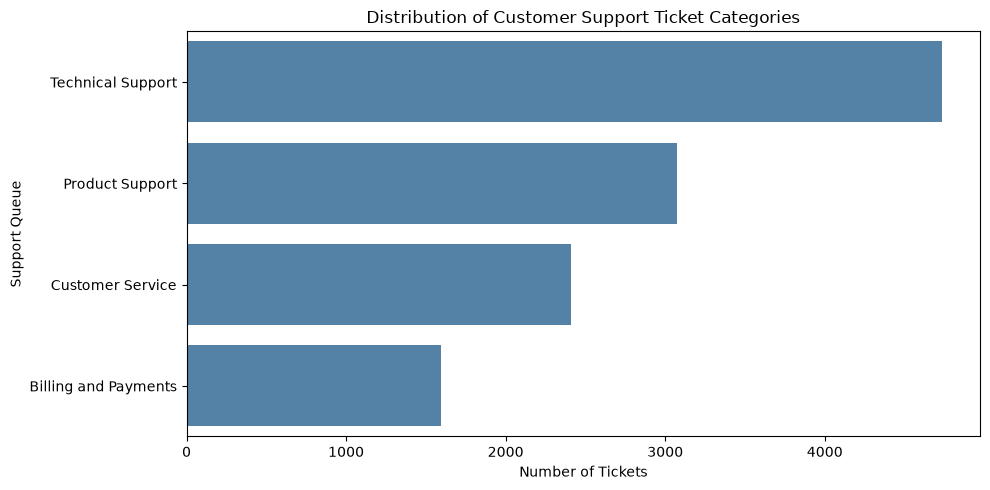

In [34]:
# horizontal bar chart
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="queue",
    order=category_counts.index,
    color="steelblue",
)

plt.title("Distribution of Customer Support Ticket Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Support Queue")
plt.tight_layout()
plt.show()

### **Observations**

1. Technical Support has most tickets
2. Billing and Payments has the fewest
3. The dataset is not balanced
4. The dataset is moderately imbalanced. Technical Support has almost three times as many examples as Billing and Payments. This may cause the model to favor the majority class, while overall accuracy could hide weak performance on smaller classes. Therefore, per-class metrics and macro F1 should be evaluated.

In [35]:
# Calculate ticket lengths

df["word_count"] = df["ticket_text"].str.split().str.len()
df["character_count"] = df["ticket_text"].str.len()

In [36]:
df[["ticket_text", "word_count", "character_count"]].head()

,ticket_text,word_count,character_count
0,"Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is...",84,563
1,"Inquiry Regarding Invoice Details Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to m...",95,639
2,"Feature Query Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the features of one of your products. Would you be able to share comprehensiv...",99,660
3,"Connectivity Problems with Printer on MacBook Pro Dear Support Team,\n\nI am reporting a recurring issue with the Laser Printer when printing from MacBook Pros running macOS 15. Several team membe...",83,563
4,"VPN Access Issue Customer Support,\n\nWe are encountering a disruption in VPN-router connectivity that is impacting several devices, notably essential remote telemedicine systems and EMR integrati...",81,600


In [37]:
#Summary stats
df[["word_count", "character_count"]].describe()

,word_count,character_count
count,11814.000000,11814.000000
mean,58.838581,406.469951
std,26.696099,178.277221
min,3.000000,18.000000
25%,37.000000,257.000000
50%,60.000000,416.000000
75%,82.000000,565.750000
max,172.000000,1189.000000


In [38]:
#calculate the median and 95th percentile:

print(f"Median word count: {df['word_count'].median():.0f}")
print(f"95th percentile: {df['word_count'].quantile(0.95):.0f}")

Median word count: 60
95th percentile: 96


In [39]:
#Inspect shortest tickets

pd.set_option("display.max_colwidth", 200)

shortest_tickets = df.nsmallest(5, "word_count")[
    ["ticket_text", "queue", "word_count"]]

shortest_tickets

,ticket_text,queue,word_count
4252,Hello support team,Customer Service,3
734,Issue Encountered Assistance Needed,Technical Support,4
2394,Several products are impacted,Technical Support,4
2733,Several products are impacted.,Technical Support,4
6773,Seek assistance with billing,Billing and Payments,4


In [40]:
longest_tickets = df.nlargest(5, "word_count")[
    ["ticket_text", "queue", "word_count"]
]

longest_tickets

,ticket_text,queue,word_count
2709,"Immediate Update Needed for SaaS Platform Dear Customer Support,\n\nI am requesting an update and optimization for our SaaS platform, which integrates multiple affected products. Currently, the pl...",Customer Service,172
1025,"Urgent Update Needed for SaaS Platform Dear Customer Support,\n\nI am requesting an update and optimization for the SaaS platform, which integrates multiple affected products. The current platform...",Customer Service,165
3157,"Assistance Needed with Integration Issue Dear Customer Support Team,\n\nI am reporting an issue with multiple product integrations, including FL Studio Shopify, where the synchronization with the ...",Billing and Payments,162
186,"Request for Complete Product Support Documentation Dear Customer Support Team,\n\nI hope this message reaches you well. I am writing to request in-depth documentation related to your product servi...",Product Support,154
2528,"Acknowledgment of Report Writing Issue in Data Analytics System I am writing to acknowledge the issue with the data analytics system, which has failed to optimize investments as expected despite o...",Product Support,153


In [41]:
#Removing malformed tickets

malformed_mask = (
    (df["word_count"] < 5)
    & (df["character_count"] > 100)
)

print(f"Clearly malformed tickets: {malformed_mask.sum()}")

Clearly malformed tickets: 0


In [42]:
analysis_df = df[~malformed_mask].copy()
analysis_df = analysis_df.reset_index(drop=True)

print(f"Rows before removal: {df.shape[0]}")
print(f"Rows after removal: {analysis_df.shape[0]}")

Rows before removal: 11814
Rows after removal: 11814


### **Plot ticket-length distribution**

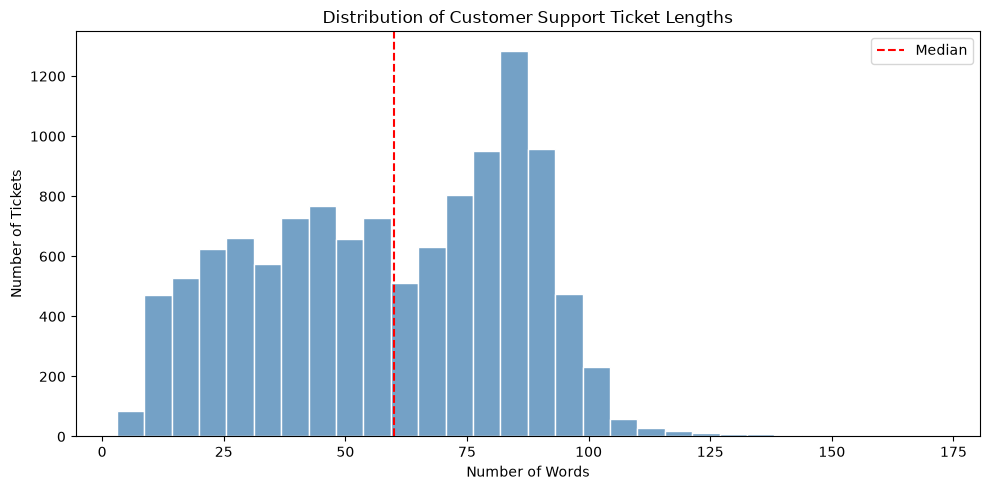

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=analysis_df,
    x="word_count",
    bins=30,
    color="steelblue",
    edgecolor="white",
)

plt.axvline(
    analysis_df["word_count"].median(),
    color="red",
    linestyle="--",
    label="Median",
)

plt.title("Distribution of Customer Support Ticket Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.legend()
plt.tight_layout()
plt.show()

### **Observations**

- Ticket lengths cover a broad range, with the tallest histogram interval appearing near 90 words. The median ticket length is 60 words.
- A longer right tail extends toward high word counts.
- A longer left tail extends toward low word counts.
- Ticket lengths have a slightly left-skewed distribution, with most tickets concentrated around the middle-to-higher word-count range and a tail extending toward shorter tickets. The mean of 58.83 words is slightly lower than the median of 60 words. Extremely long tickets are rare.
- Ticket-length distributions are similar across all four support queues. Average lengths differ by fewer than two words, and median lengths range from 59 to 61 words. Therefore, ticket length does not appear to be a strong distinguishing feature for queue classification.

In [44]:
length_by_queue = (
    analysis_df.groupby("queue")["word_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

length_by_queue

,count,mean,median,min,max
queue,,,,,
Billing and Payments,1595,59.43,61.0,4,162
Customer Service,2410,58.88,61.0,3,172
Technical Support,4736,59.05,61.0,4,153
Product Support,3073,58.18,59.0,6,154


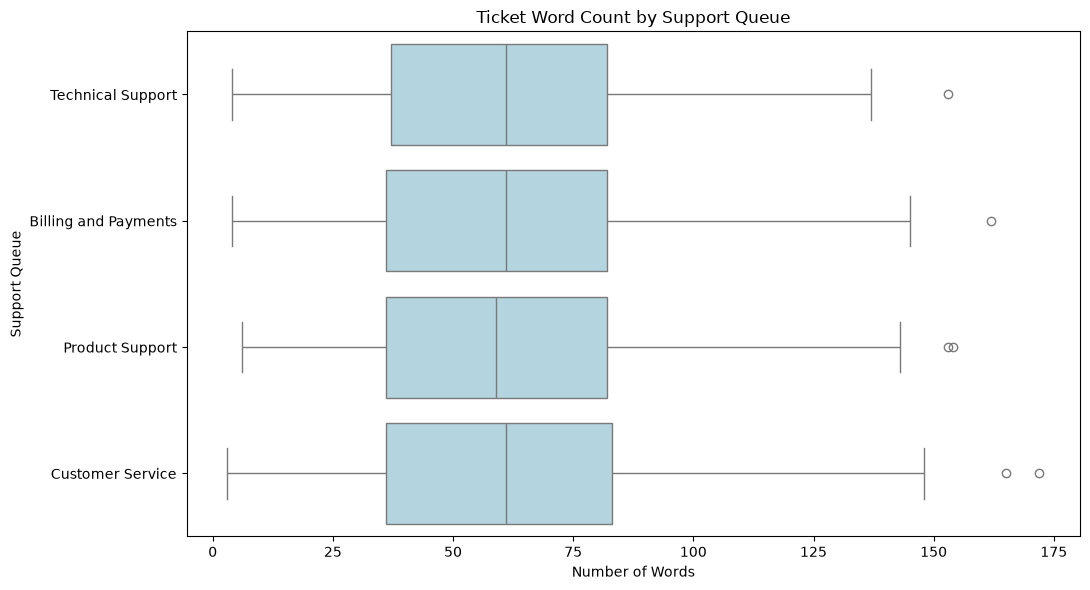

In [45]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=analysis_df,
    x="word_count",
    y="queue",
    color="lightblue",
)

plt.title("Ticket Word Count by Support Queue")
plt.xlabel("Number of Words")
plt.ylabel("Support Queue")
plt.tight_layout()
plt.show()

### **Observations**
- The boxes overlap substantially and the category medians are similar. Although some categories contain long-ticket outliers, ticket length does not clearly distinguish the four queues. The classifier must therefore rely primarily on ticket vocabulary and context rather? no
- The medians are very similar.
- high-length outliers for Product Support and Customer Service.
- Word count is unlikely to separate the categories.

### **category length box plot**

In [46]:
df["word_count"] = df["ticket_text"].str.split().str.len()
df["character_count"] = df["ticket_text"].str.len()

In [47]:
print(df.columns.tolist())

['ticket_text', 'queue', 'word_count', 'character_count']


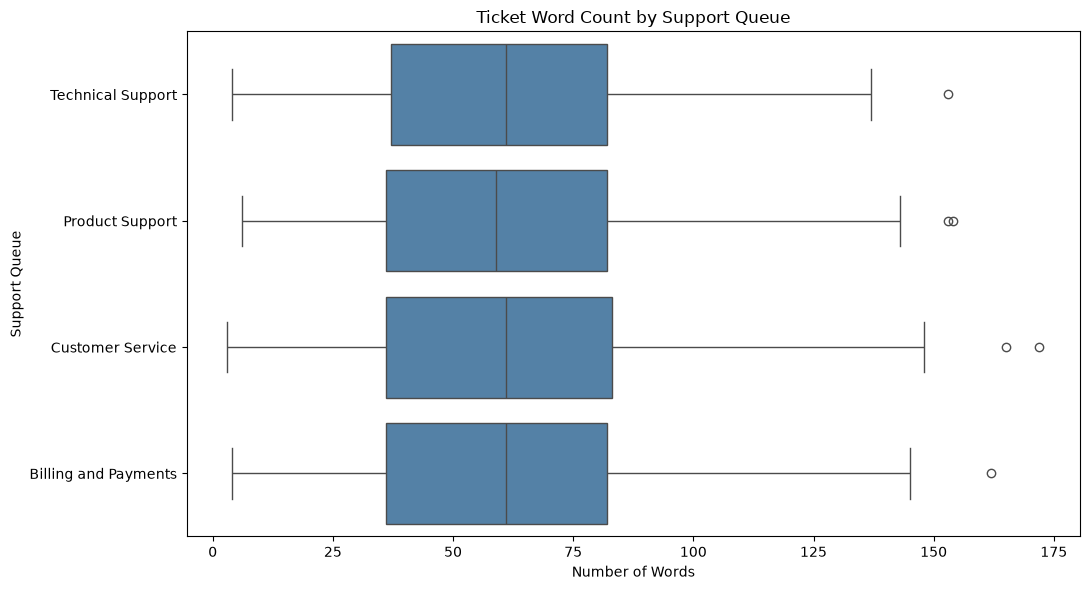

In [48]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="word_count",
    y="queue",
    order=category_counts.index,
    color="steelblue",
    showfliers=True,
)

plt.title("Ticket Word Count by Support Queue")
plt.xlabel("Number of Words")
plt.ylabel("Support Queue")
plt.tight_layout()
plt.show()

## Day 4 Conclusions

- The dataset contains four moderately imbalanced categories.
- Technical Support is the largest category, while Billing and Payments is the smallest.
- The largest class contains approximately 2.97 times as many tickets as the smallest.
- Ticket lengths are slightly left-skewed, with a median of approximately 60 words.
- Most tickets contain 96 words or fewer.
- Ticket-length distributions and overlap considerably across queues.
- Ticket length alone is therefore unlikely to predict the correct queue.
- Manual inspection identified one malformed ticket with missing spaces.
- The malformed record was excluded through the reproducible cleaning pipeline.
- Some synthetic tickets have ambiguous or potentially noisy queue labels.
- Model evaluation should include macro F1 and per-class metrics rather than accuracy alone.